# Дескриптивный анализ целевых датасетов домохозяйств
Детальное профилирование структуры, объемов, типов данных, пропусков и ключевых свойств 4 целевых датасетов БНС РК **до объединения**, а также расчет первичных финансовых метрик.

---

### Выбранные датасеты для анализа:
1. `d008`: Состав домохозяйств (списочный ростер членов семьи, демография)
2. `d006`: Жилищные условия (площадь, тип жилья, благоустройство)
3. `d004`: Квартальные расходы (питание `vopr11`, кредиты `vopr12`, непродовольственные товары `vopr1`)
4. `d002`: Субъективная оценка финансового положения



## 1. Настройка окружения и загрузка библиотек


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)


Библиотеки успешно импортированы.


## 2. Профилирование и свойства датасетов

- Проверка размера файла и количества записей.
- Проверка типов данных и пропущенных значений (`Null / NaN`).
- Проверка уникальности домохозяйственного ключа **`NOMER`**.



### 2.1. Датасет `d008` (Демография и ростер членов семьи)


In [ ]:
f_d008 = glob.glob('d008/2024/**/*.csv', recursive=True)[0]
file_size_d008 = os.path.getsize(f_d008) / (1024 * 1024)
df_d008_raw = pd.read_csv(f_d008)

print(f"Файл: {f_d008}")
print(f"Размер файла: {file_size_d008:.2f} MB")
print(f"Записей (человек): {len(df_d008_raw):,}")
print(f"Уникальных домохозяйств (NOMER): {df_d008_raw['NOMER'].nunique():,}")
print(f"Среднее число членов на ДХ: {len(df_d008_raw) / df_d008_raw['NOMER'].nunique():.2f}")
print("Пропуски по колонкам (только с пропусками)")
nulls_d008 = df_d008_raw.isnull().sum()
print(nulls_d008[nulls_d008 > 0] if (nulls_d008 > 0).any() else "Пропусков нет")

display(df_d008_raw[['NOMER', 'NOMP', 'RODSTVO', 'POL', 'ROST', 'SEM_POL', 'UROV']].head())


📁 Файл: d008/2024\kontr_k.csv
📊 Размер файла: 3.07 MB
🔢 Записей (человек): 41,821
🔑 Уникальных домохозяйств (NOMER): 12,000
👥 Среднее число членов на ДХ: 3.49

-- Пропуски по колонкам (только с пропусками) --
SEM_POL     13222
UROV          686
VR_OTS      41504
PR_IZA      41220
PR_IZI      40853
PR_IZO      40315
PR_IZYA     40018
STATUS      12726
STATUSF     40478
STATUS1     12523
STATUSF1    40466
STATUS2     12619
STATUSF2    40402
STATUS3     12669
STATUSF3    40392
STATUS4     12547
STATUSF4    40442
ZT          41821
FIZ          1412
FIZM        35281
FIZCH       35227
dtype: int64


,NOMER,NOMP,RODSTVO,POL,ROST,SEM_POL,UROV
0,2024000001,1,1,1,175,2.0,5.0
1,2024000001,2,2,2,160,2.0,4.0
2,2024000002,1,1,2,169,4.0,4.0
3,2024000002,2,2,2,163,2.0,4.0
4,2024000002,3,3,2,170,NaN,2.0


### 2.2. Датасет `d006` (Жилищные условия)


In [ ]:
f_d006 = glob.glob('d006/2024/**/*.csv', recursive=True)[0]
file_size_d006 = os.path.getsize(f_d006) / (1024 * 1024)
df_d006_raw = pd.read_csv(f_d006)

print(f"Файл: {f_d006}")
print(f"Размер файла: {file_size_d006:.2f} MB")
print(f"Строк (домохозяйств): {len(df_d006_raw):,}")
print(f"Уникальных NOMER: {df_d006_raw['NOMER'].nunique():,}")
print(f"Процент совпадения 1 строка = 1 ДХ: {(len(df_d006_raw) == df_d006_raw['NOMER'].nunique())}")
print("Пропуски по основным жилищным полям")
print(df_d006_raw[['NOMER', 'TIP_J', 'OB_PL', 'J_PL', 'KOL_K']].isnull().sum())

display(df_d006_raw[['NOMER', 'TE', 'K', 'TIP_J', 'OB_PL', 'J_PL', 'KOL_K']].head())


📁 Файл: d006/2024\rio_2024.csv
📊 Размер файла: 3.85 MB
🔢 Строк (домохозяйств): 11,704
🔑 Уникальных NOMER: 11,704
🏠 Процент совпадения 1 строка = 1 ДХ: True

-- Пропуски по основным жилищным полям --
NOMER    0
TIP_J    0
OB_PL    0
J_PL     0
KOL_K    0
dtype: int64


,NOMER,TE,K,TIP_J,OB_PL,J_PL,KOL_K
0,2024000001,43,1,4,67,42,3
1,2024000002,31,2,1,86,66,5
2,2024000003,75,1,4,42,25,2
3,2024000004,39,2,1,58,41,3
4,2024000005,10,1,4,54,37,3


### 2.3. Датасет `d004` (Квартальные расходы и кредиты)


In [ ]:
f_v11 = glob.glob('d004/2024/**/kv_vopr11.csv', recursive=True)[0] # Еда
f_v12 = glob.glob('d004/2024/**/kv_vopr12.csv', recursive=True)[0] # Кредиты/Долги
f_v1 = glob.glob('d004/2024/**/kv_vopr1.csv', recursive=True)[0]   # Непроды

df_v11_raw = pd.read_csv(f_v11)
df_v12_raw = pd.read_csv(f_v12)
df_v1_raw = pd.read_csv(f_v1)

print(f"vopr11 (Питание): {len(df_v11_raw):,} строк, {df_v11_raw['NOMER'].nunique():,} ДХ")
print(f"vopr12 (Кредиты/Долги): {len(df_v12_raw):,} строк, {df_v12_raw['NOMER'].nunique():,} ДХ имеющих кредиты")
print(f"vopr1 (Непродовольственные): {len(df_v1_raw):,} строк, {df_v1_raw['NOMER'].nunique():,} ДХ")

# Агрегация расходов по ДХ
gr_cols = [c for c in df_v11_raw.columns if c.startswith('GR')]
df_v11_raw['TOTAL_FOOD'] = df_v11_raw[gr_cols].sum(axis=1)
exp_food = df_v11_raw.groupby('NOMER')['TOTAL_FOOD'].sum().reset_index(name='EXP_FOOD')

exp_debt = df_v12_raw.groupby('NOMER')['STOIMK'].sum().reset_index(name='EXP_DEBT')
exp_other = df_v1_raw.groupby('NOMER')['STOIMK'].sum().reset_index(name='EXP_OTHER')

print("Пример сгруппированных расходов на 1 ДХ")
display(exp_food.head())


🥩 vopr11 (Питание): 24,535 строк, 11,913 ДХ
💳 vopr12 (Кредиты/Долги): 6,882 строк, 4,235 ДХ имеющих кредиты
🛒 vopr1 (Непродовольственные): 269,130 строк, 11,958 ДХ

-- Пример сгруппированных расходов на 1 ДХ --


,NOMER,EXP_FOOD
0,2024000001,976000
1,2024000002,1180959
2,2024000003,968149
3,2024000004,243000
4,2024000005,669735


### 2.4. Датасет `d002` (Субъективная оценка финансового положения)


In [ ]:
f_d002 = glob.glob('d002/2024/**/subject.csv', recursive=True)[0]
df_d002_raw = pd.read_csv(f_d002)

print(f"Файл: {f_d002}")
print(f"Строк: {len(df_d002_raw):,}")
print(f"Уникальных NOMER: {df_d002_raw['NOMER'].nunique():,}")

# 1 респондент на ДХ для объединения
df_d002_sub = df_d002_raw.drop_duplicates(subset=['NOMER'])[['NOMER', 'GR1']].rename(columns={'GR1': 'SUBJECTIVE_STATUS'})
display(df_d002_sub.head())


📁 Файл: d002/2024\subject.csv
🔢 Строк: 11,931
🔑 Уникальных NOMER: 11,931


,NOMER,SUBJECTIVE_STATUS
0,2024000001,7
1,2024000002,10
2,2024000003,8
3,2024000004,7
4,2024000005,10


## 3. Объединение датасетов (Merge) по ключу `NOMER`

После подтверждения целостности ключей объединяем демографию, жилье, расходы и субъективные оценки.



In [ ]:
# Агрегируем d008 до уровня домохозяйства
hh_d008 = df_d008_raw.groupby('NOMER').agg(
    KOL_CHL=('NOMP', 'count'),
    CHILDREN_COUNT=('ROST', lambda x: (x < 18).sum()),
    AVG_AGE=('ROST', 'mean')
).reset_index()

# Базовые поля d006
hh_d006 = df_d006_raw[['NOMER', 'TE', 'K', 'TIP_J', 'OB_PL', 'J_PL', 'KOL_K']].copy()

# Последовательный Merge
df_merged = pd.merge(hh_d008, hh_d006, on='NOMER', how='inner')
df_merged = pd.merge(df_merged, exp_food, on='NOMER', how='left').fillna({'EXP_FOOD': 0})
df_merged = pd.merge(df_merged, exp_debt, on='NOMER', how='left').fillna({'EXP_DEBT': 0})
df_merged = pd.merge(df_merged, exp_other, on='NOMER', how='left').fillna({'EXP_OTHER': 0})
df_merged = pd.merge(df_merged, df_d002_sub, on='NOMER', how='left')

print(f"Итоговый датасет: {df_merged.shape[0]:,} домохозяйств, {df_merged.shape[1]} полей.")


✅ Объединение завершено! Итоговый датасет: 11,704 домохозяйств, 14 полей.


## 4. Расчет ключевых производных метрик (Feature Engineering)

Добавляем 4 важнейших аналитических показателя:
1. `TOTAL_EXPENSE` = Общие суммарные расходы домохозяйства
2. `SQM_PER_CAPITA` = Обеспеченность жилой площадью (м² на 1 человека)
3. `ENGEL_FOOD_SHARE` = Коэффициент Энгеля (доля трат на продукты от общих расходов)
4. `DEBT_BURDEN_RATIO` = Долговая нагрузка (доля трат на кредиты и долги)



In [21]:
df_merged['TOTAL_EXPENSE'] = df_merged['EXP_FOOD'] + df_merged['EXP_DEBT'] + df_merged['EXP_OTHER']
df_merged['SQM_PER_CAPITA'] = (df_merged['OB_PL'] / df_merged['KOL_CHL']).round(1)

df_merged['ENGEL_FOOD_SHARE'] = np.where(df_merged['TOTAL_EXPENSE'] > 0, (df_merged['EXP_FOOD'] / df_merged['TOTAL_EXPENSE']).round(3), 0)
df_merged['DEBT_BURDEN_RATIO'] = np.where(df_merged['TOTAL_EXPENSE'] > 0, (df_merged['EXP_DEBT'] / df_merged['TOTAL_EXPENSE']).round(3), 0)

display(df_merged[['NOMER', 'KOL_CHL', 'OB_PL', 'SQM_PER_CAPITA', 'TOTAL_EXPENSE', 'ENGEL_FOOD_SHARE', 'DEBT_BURDEN_RATIO']].head())


,NOMER,KOL_CHL,OB_PL,SQM_PER_CAPITA,TOTAL_EXPENSE,ENGEL_FOOD_SHARE,DEBT_BURDEN_RATIO
0,2024000001,2,67,33.5,1108850.0,0.880,0.000
1,2024000002,3,86,28.7,1412979.0,0.836,0.000
2,2024000003,2,42,21.0,1557149.0,0.622,0.302
3,2024000004,3,58,19.3,441802.0,0.550,0.000
4,2024000005,2,54,27.0,797480.0,0.840,0.000


## 5. Итоговая дескриптивная статистика


In [22]:
# Таблица основных статистических показателей
metrics = ['KOL_CHL', 'CHILDREN_COUNT', 'OB_PL', 'SQM_PER_CAPITA', 'TOTAL_EXPENSE', 'ENGEL_FOOD_SHARE', 'DEBT_BURDEN_RATIO']
summary_table = df_merged[metrics].describe(percentiles=[0.25, 0.50, 0.75]).T
summary_table['median'] = df_merged[metrics].median()

summary_table = summary_table[['count', 'mean', 'median', 'std', 'min', '25%', '75%', 'max']]
display(summary_table.round(2))


,count,mean,median,std,min,25%,75%,max
KOL_CHL,11704.0,3.49,3.00,1.92,1.0,2.00,5.00,12.00
CHILDREN_COUNT,11704.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00
OB_PL,11704.0,72.99,64.00,35.00,12.0,50.00,85.00,291.00
SQM_PER_CAPITA,11704.0,27.89,21.50,21.27,2.5,14.20,34.30,287.00
TOTAL_EXPENSE,11704.0,1343805.66,1198766.50,861410.54,0.0,795584.00,1715568.50,19977810.00
ENGEL_FOOD_SHARE,11704.0,0.78,0.83,0.17,0.0,0.71,0.90,1.00
DEBT_BURDEN_RATIO,11704.0,0.07,0.00,0.13,0.0,0.00,0.08,0.97


## 6. Графический дескриптивный анализ


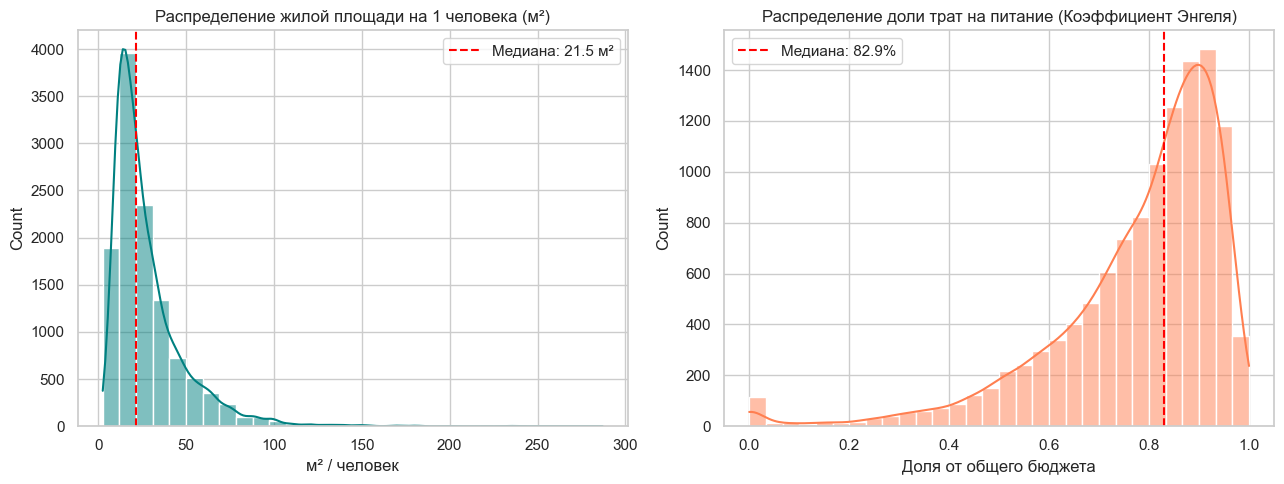

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Гистограмма 1: Площадь жилья на человек
sns.histplot(df_merged['SQM_PER_CAPITA'], kde=True, ax=axes[0], color='teal', bins=30)
axes[0].set_title('Распределение жилой площади на 1 человека (м²)')
axes[0].set_xlabel('м² / человек')
axes[0].axvline(df_merged['SQM_PER_CAPITA'].median(), color='red', linestyle='--', label=f"Медиана: {df_merged['SQM_PER_CAPITA'].median():.1f} м²")
axes[0].legend()

# Гистограмма 2: Коэффициент Энгеля (доля трат на еду)
sns.histplot(df_merged['ENGEL_FOOD_SHARE'], kde=True, ax=axes[1], color='coral', bins=30)
axes[1].set_title('Распределение доли трат на питание (Коэффициент Энгеля)')
axes[1].set_xlabel('Доля от общего бюджета')
axes[1].axvline(df_merged['ENGEL_FOOD_SHARE'].median(), color='red', linestyle='--', label=f"Медиана: {df_merged['ENGEL_FOOD_SHARE'].median():.1%}")
axes[1].legend()

plt.tight_layout()
plt.show()
